++ Read in data array with dimensions: 60, 67, 144
   The first two are spatial dimensions, and the third is time.
++ Read in reference time series of length: 144
Shape 1D : (4020,)
Shape after reconstruction (60, 67)
reconstruction matches orginal:  True


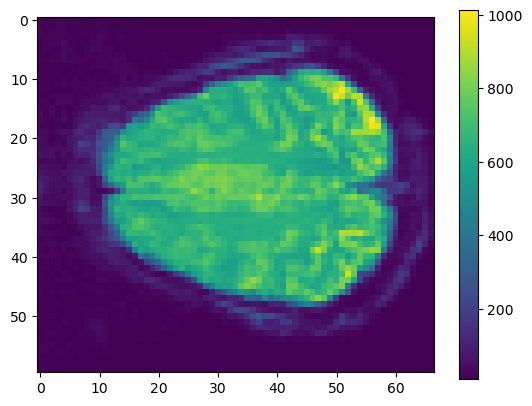

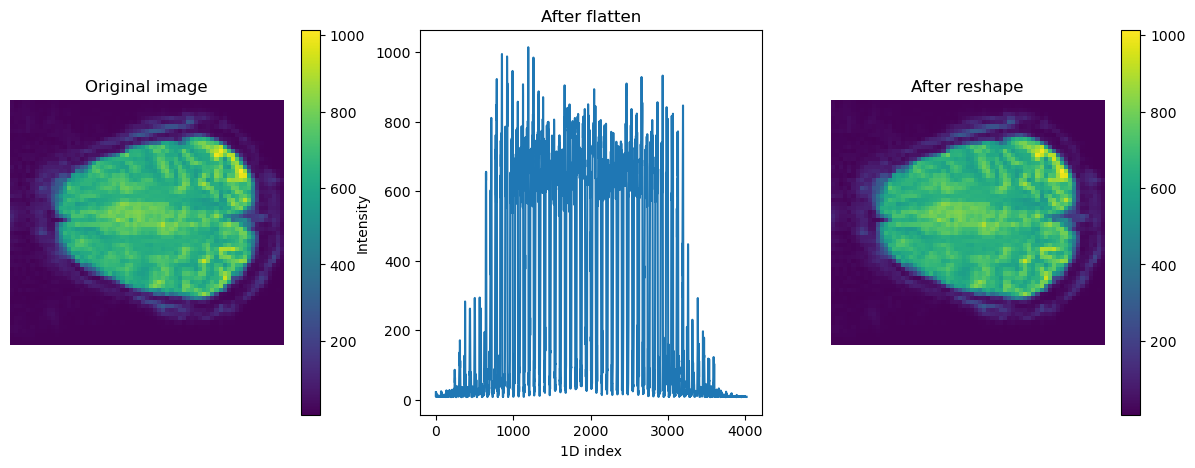

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================================================
# background functions: provided to read data

def read_in_dataset(fname):
    """
Parameters
----------
fname_dat : str
    filename of data (of the particular dimensions included in this function)

Returns
-------
data : np.ndarray
    3D array of data, representing a slice of data (first 2 coords) and a time
    series at each location (3rd dimension)
"""

    # read in: brain time series data
    fff = open(fname, "r")
    X = fff.readlines()
    fff.close()
    brain = [line.split() for line in X]

    # dimensions of brain data (slice + time)
    N = 144
    dimx = 70-11+1
    dimy = 74-8+1

    # brain data: initialize+populate
    data = np.zeros((dimx,dimy,N))
    n = 0
    for j in range(0,dimy):
        for i in range(0,dimx):
            for k in range(0,N):
                # don't need these coord values, but just keep track
                x = brain[n][0]
                y = brain[n][1]
                z = brain[n][2]
                data[i,j,k] = brain[n][3+k]
            n+=1

    Nx, Ny, Nt = np.shape(data)

    print("++ Read in data array with dimensions: {}, {}, {}\n"
          "   The first two are spatial dimensions, and the third is time."
          "".format(Nx, Ny, Nt))

    return data

def read_in_refwav(fname):
    """Read in a file fname that contains a single reference time series.

Parameters
----------
fname_ref : str
    filename of reference wave (of particular len included in this function)

Returns
-------
refwav : np.ndarray
    1D array of data, representing reference time series
"""

    # read in: brain time series data
    fff = open(fname, "r")
    X = fff.readlines()
    fff.close()
    boxcar = [line.split() for line in X]

    # dimensions of reference wave (number of time points)
    N = len(boxcar)

    # make refwav
    refwav = np.zeros(N)
    for k in range(0,N):
        refwav[k] = boxcar[k][0]

    print("++ Read in reference time series of length: {}"
          "".format(N))

    return refwav

# =========================================================================

if __name__ == "__main__":
    
    # read in a slice of FMRI data (3D array): first 2 dims are
    # spatial indices, and third is index of time points
    data = read_in_dataset("AIMSftap.dat")
    Nx, Ny, Nt = np.shape(data)

    # the sampling time for this data
    Ts = 2.5

    # read in a reference time series (1D array)
    refwav = read_in_refwav("Ref.1D")
    L = len(refwav)    

    data_mean = np.zeros((Nx, Ny))
    for i in range(Nx):
        for j in range(Ny):
            data_mean[i,j] = np.mean(data[i,j,:])

    #flaten 
    data_flat = data_mean.flatten()
    print(f"Shape 1D : {data_flat.shape}")

    #reshape
    data_reconstructed = data_flat.reshape(Nx,Ny)
    print(f"Shape after reconstruction {data_reconstructed.shape}")

    are_equal = np.allclose(data_mean, data_reconstructed)
    print(f"reconstruction matches orginal:  {are_equal}")
    plt.imshow(data_mean)
    plt.colorbar()



    #visual 
    fig, axes = plt.subplots(1,3, figsize = (15,5))
    im0 = axes[0].imshow(data_mean)
    axes[0].set_title('Original image')
    axes[0].axis('off')
    plt.colorbar(im0, ax = axes[0])


    axes[1].plot(data_flat)
    axes[1].set_title("After flatten")
    axes[1].set_xlabel('1D index')
    axes[1].set_ylabel('Intensity')

    im2 = axes[2].imshow(data_reconstructed)
    axes[2].set_title("After reshape")
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])

    plt.savefig("visual1.png")

    plt.show()

PC  1 - r = 0.001, p = 0.9928
PC  2 - r = 0.235, p = 0.0047
PC  3 - r = -0.486, p = 0.0000
PC  4 - r = 0.071, p = 0.3968
PC  5 - r = 0.103, p = 0.2182
PC  6 - r = -0.074, p = 0.3810
PC  7 - r = -0.299, p = 0.0003
PC  8 - r = -0.000, p = 0.9960
PC  9 - r = -0.033, p = 0.6980
PC 10 - r = 0.086, p = 0.3082

→ Best PC: PC 3 (r=-0.486, p=0.0000)


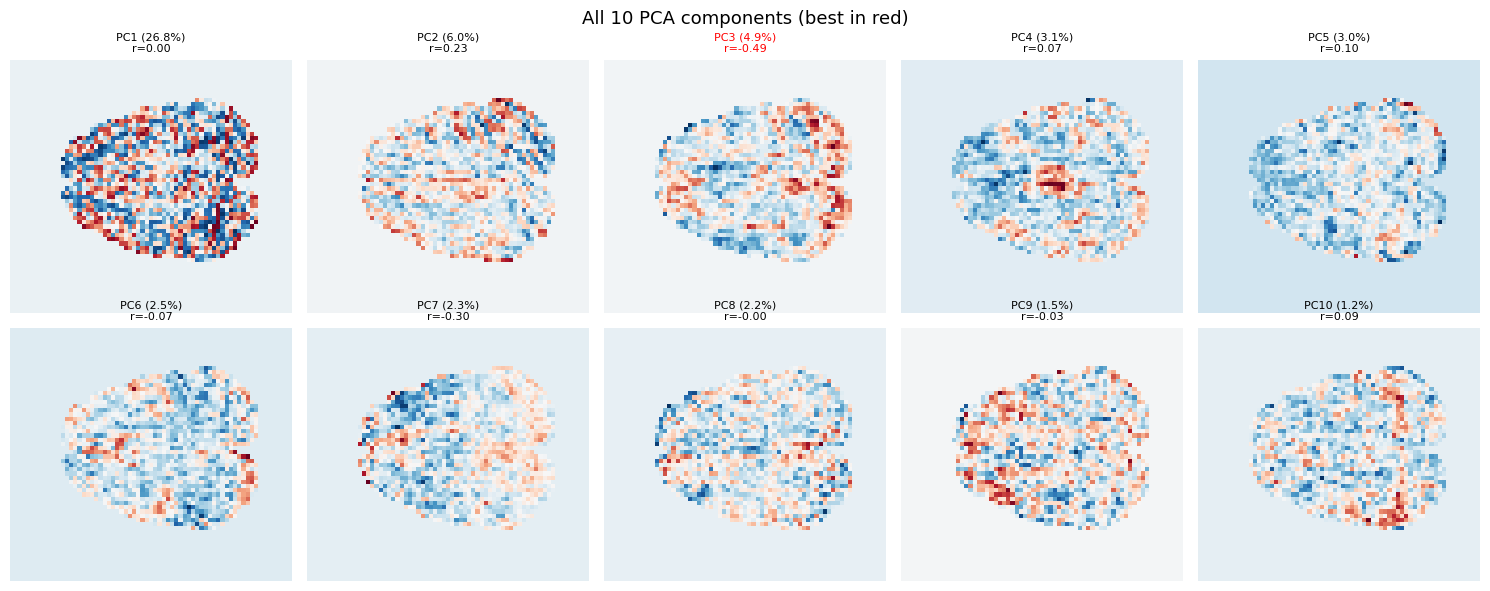

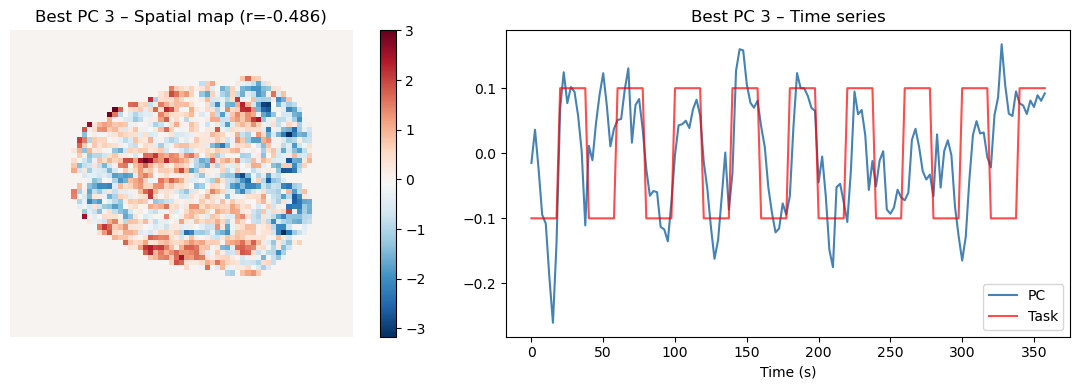

In [28]:
from sklearn.decomposition import PCA
from scipy.stats import zscore

data_flat = data.reshape(Nx*Ny, Nt)

data_mean_flat = data_flat.mean(axis=1)
mask = data_mean_flat >500
data_masked = data_flat[mask, :]

data_masked_z = zscore(data_masked, axis = 1)

n_components = 10
pca = PCA(n_components = n_components, whiten = True)
scores = pca.fit_transform(data_masked_z)


time = np.arange(Nt)*Ts
correlations = []

for i in range(n_components):
    r,p = pearsonr (pca.components_[i], refwav)
    correlations.append((abs(r),r, p, i))
    print("PC {:2d} - r = {:.3f}, p = {:.4f}".format(i+1, r, p))
    
best = max(correlations, key = lambda x:x[0])
best_idx = best[3]
print("\n→ Best PC: PC {} (r={:.3f}, p={:.4f})".format(best_idx+1, best[1], best[2]))

ncols = 5
nrows = n_components//ncols

fig, axes = plt.subplots(nrows, ncols, figsize = (15,3*nrows))

for i in range(n_components):
    ax = axes[i // ncols, i % ncols]
    spatial_flat = np.zeros(Nx * Ny)
    spatial_flat[mask] = scores[:, i]
    r = correlations[i][1]
    ax.imshow(spatial_flat.reshape(Nx, Ny), cmap='RdBu_r')
    title_color = 'red' if i == best_idx else 'black'
    ax.set_title("PC{} ({:.1f}%)\nr={:.2f}".format(
        i+1, pca.explained_variance_ratio_[i]*100, r), 
        fontsize=8, color=title_color)
    ax.axis('off')
plt.suptitle("All {} PCA components (best in red)".format(n_components), fontsize=13)
plt.tight_layout()
plt.savefig("components.png")
plt.show()


sign = np.sign(best[1]) 
spatial_flat = np.zeros(Nx * Ny)
spatial_flat[mask] = sign * scores[:, best_idx]
task_map = spatial_flat.reshape(Nx, Ny)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(task_map, cmap='RdBu_r')
axes[0].set_title("Best PC {} – Spatial map (r={:.3f})".format(best_idx+1, best[1]))
axes[0].axis('off')
plt.colorbar(im, ax=axes[0])

refwav_norm = (refwav - refwav.mean()) / refwav.std() * 0.1
axes[1].plot(time, sign * pca.components_[best_idx], color='steelblue', label='PC')
axes[1].plot(time, refwav_norm, color='red', alpha=0.7, label='Task')
axes[1].set_title("Best PC {} – Time series".format(best_idx+1))
axes[1].set_xlabel("Time (s)")
axes[1].legend()
plt.tight_layout()
plt.savefig("best_component.png")
plt.show()

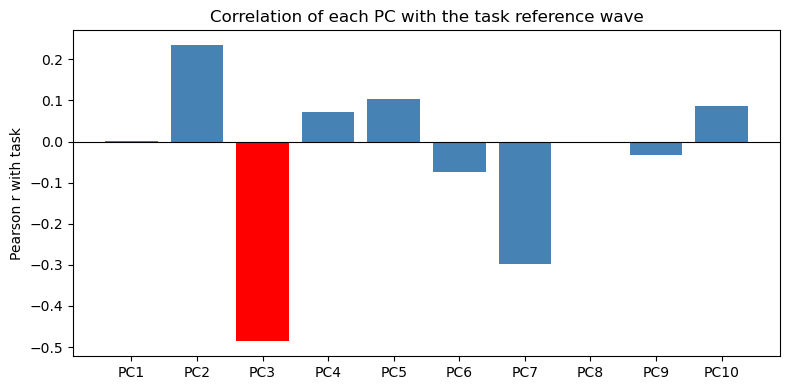

In [30]:
correlations = [pearsonr(pca.components_[i], refwav)[0] for i in range(n_components)]

plt.figure(figsize=(8, 4))
colors = ['red' if abs(r) == max(abs(c) for c in correlations) else 'steelblue' 
          for r in correlations]
plt.bar(["PC{}".format(i+1) for i in range(n_components)], correlations, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Pearson r with task")
plt.title("Correlation of each PC with the task reference wave")
plt.tight_layout()
plt.savefig("correlation_bar.png")
plt.show()